# Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [2]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240607 - Ag60 GDE_0.9 M K2SO4_pH2

10-Aug-26  04:53 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  09:14 PM    <DIR>          .ipynb_checkpoints
10-Jun-24  02:41 PM           138,135 0p9M_pH2 K2SO4_20240610_1240_1min - Copy.xlsx
29-Jul-26  06:49 PM            90,150 0p9M_pH2 K2SO4_20240610_1240_1min.xlsx
10-Jun-24  02:41 PM            32,483 0p9M_pH2 K2SO4_20240610_1240_5min.xlsx
10-Jun-24  02:40 PM           942,761 0p9M_pH2 K2SO4_20240610_1240_Line_1.csv
12-May-25  11:31 AM           850,234 20240607 - Ag60 GDE_0.9 M K2SO4_pH2.ipynb
04-Aug-26  08:07 PM           668,156 20240607 - Ag60 GDE_0.9 M K2SO4_pH2-CORRECTED.ipynb
04-Aug-26  08:54 AM               573 20240607_0.9 M K2SO4_pH2_Energy Consumption.csv
04-Aug-26  08:05 PM             5,070 20240607_0.9M K2SO4_pH2.csv
03-Aug-26  05:50 PM               748 20

# Load Data

In [3]:
Book = "Book_20240607 - Ag60 GDE_0.9 M K2SO4_pH2.xlsx"
Book = pd.read_excel(Book)
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,55.154546,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-07 16:53:28.280,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
1,Ag60 GDE in PTFE holder,60,58.892861,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 17:19:44.000,0.437700,0.850289,...,0.007874,0.006581,0.983153,0.000709,0.491027,0.410371,NaN,0.901398,0.006649,NaN
2,Ag60 GDE in PTFE holder,60,59.457116,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 17:42:16.000,0.813256,1.006437,...,0.009329,0.005828,0.983499,0.000386,0.587292,0.366887,NaN,0.954180,0.005891,106.732793


In [4]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
122,Ag60 GDE in PTFE holder,60,60.81,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-09 17:53:57,49.01,0.000000,...,0.0,1.000000,0.0,0.000000,0.0,NaN,0.000000,0.0,107.393828,60.81
123,Ag60 GDE in PTFE holder,60,61.50,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-09 18:16:28,49.38,0.000000,...,0.0,1.000000,0.0,0.000000,0.0,NaN,0.000000,0.0,NaN,61.50
124,Ag60 GDE in PTFE holder,60,61.68,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-09 18:38:58,49.76,0.008978,...,0.0,0.999894,0.0,0.001363,0.0,NaN,0.001363,0.0,107.522325,61.68


### Temp from pH meter

In [5]:
Temp = "2024-06-08_102747.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 24.659151193633953
Temp C median: 23.6


### Power Supply

In [6]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.00V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,07.06.2024 16:53:28.280
1,40.00V,2.48V,0.100A,0.116A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,07.06.2024 16:53:33.267


In [7]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.00V
0.100A 1    2.48V
       2    2.54V

In [8]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                  Time  I actual  U actual
0  2024-06-07 16:00:00     0.122      3.11
1  2024-06-07 18:00:00     0.273      3.61
2  2024-06-07 20:00:00     0.521      4.19
3  2024-06-07 22:00:00     0.765      4.81
4  2024-06-08 00:00:00     1.019      5.30
5  2024-06-08 02:00:00     1.519      6.28
6  2024-06-08 04:00:00     2.020      7.12
7  2024-06-08 06:00:00     3.016      8.94
8  2024-06-08 08:00:00     3.018      8.87
9  2024-06-08 10:00:00     1.514      6.29
10 2024-06-08 12:00:00     1.516      6.40
11 2024-06-08 14:00:00     1.518      6.28
12 2024-06-08 16:00:00     1.514      6.26
13 2024-06-08 18:00:00       NaN       NaN
14 2024-06-08 20:00:00       NaN       NaN
15 2024-06-08 22:00:00       NaN       NaN
16 2024-06-09 00:00:00       NaN       NaN
17 2024-06-09 02:00:00       NaN       NaN
18 2024-06-09 04:00:00       NaN       NaN
19 2024-06-09 06:00:00       NaN       NaN
20 2024-06-09 08:00:00       NaN       NaN
21 2024-06-09 10:00:00     1.509      5.96


In [9]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-14].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-06-07 16:00:00     0.122      3.11
1 2024-06-07 18:00:00     0.273      3.61
2 2024-06-07 20:00:00     0.521      4.19
3 2024-06-07 22:00:00     0.765      4.81
4 2024-06-08 00:00:00     1.019      5.30
5 2024-06-08 02:00:00     1.519      6.28
6 2024-06-08 04:00:00     2.020      7.12
7 2024-06-08 06:00:00     3.016      8.94


In [10]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [11]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.122,3.11
0.273,3.61
0.521,4.19
0.765,4.81
1.019,5.30
1.519,6.28
2.020,7.12
3.016,8.94


In [12]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.122,3.11,1.22
0.273,3.61,2.73
0.521,4.19,5.21
0.765,4.81,7.65
1.019,5.30,10.19
1.519,6.28,15.19
2.020,7.12,20.20
3.016,8.94,30.16


## Flow rate

In [17]:
flow_rate = "0p9M_pH2 K2SO4_20240610_1240_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-06-10 12:40:42.096000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p9M_pH2 K2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [18]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-06-07 14:53:00.010000,55.154546,27.577273
1,2024-06-07 14:53:59.971000,55.851417,27.925709
2,2024-06-07 14:55:00.019000,55.672528,27.836264
3,2024-06-07 14:55:59.981000,57.1356,28.5678
4,2024-06-07 14:57:00.029000,56.6529,28.32645
...,...,...,...
977,2024-06-08 07:09:59.990000,66.090322,33.045161
978,2024-06-08 07:11:00.038000,66.420854,33.210427
979,2024-06-08 07:12:00,65.565786,32.782893
980,2024-06-08 07:12:59.962000,66.93444,33.46722


In [19]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-07 14:00:00     55.154546      61.05337      58.632166   
1 2024-06-07 16:00:00     59.251736     62.452068      61.180942   
2 2024-06-07 18:00:00     60.586092     62.589115      61.653096   
3 2024-06-07 20:00:00     60.678826     63.723408      62.290869   
4 2024-06-07 22:00:00      61.91202     64.782663      63.182243   
5 2024-06-08 00:00:00     62.855266      67.90134      65.290588   
6 2024-06-08 02:00:00     64.881309     71.457286      68.493284   
7 2024-06-08 04:00:00     68.902917     81.216364      75.295908   
8 2024-06-08 06:00:00     64.887436     80.615804      75.888171   

  Flow_rate_median  
0        58.892861  
1        61.227536  
2        61.651663  
3         62.28194  
4        63.292082  
5        65.923794  
6        69.738342  
7        79.021298  
8        79.553278  


### Correction for dry flow

In [20]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.349 L/mol
p_sat = 2.9135 kPa -> x(H2O) = 2.88 % -> dry factor 0.97125


In [21]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [22]:
print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-07 14:00:00     55.154546      61.05337      58.632166   
1 2024-06-07 16:00:00     59.251736     62.452068      61.180942   
2 2024-06-07 18:00:00     60.586092     62.589115      61.653096   
3 2024-06-07 20:00:00     60.678826     63.723408      62.290869   
4 2024-06-07 22:00:00      61.91202     64.782663      63.182243   
5 2024-06-08 00:00:00     62.855266      67.90134      65.290588   
6 2024-06-08 02:00:00     64.881309     71.457286      68.493284   
7 2024-06-08 04:00:00     68.902917     81.216364      75.295908   
8 2024-06-08 06:00:00     64.887436     80.615804      75.888171   

  Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0        58.892861         53.568617         59.297825          56.946241   
1        61.227536         57.547996         60.656304          59.421729   
2        61.651663         58.843983         60.789411          59.880306   
3         6

In [23]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-06-07 14:00:00,55.154546,61.05337,58.632166,58.892861,53.568617,59.297825,56.946241,57.19944,0.122,3.11
1,2024-06-07 16:00:00,59.251736,62.452068,61.180942,61.227536,57.547996,60.656304,59.421729,59.466983,0.273,3.61
2,2024-06-07 18:00:00,60.586092,62.589115,61.653096,61.651663,58.843983,60.789411,59.880306,59.878915,0.521,4.19
3,2024-06-07 20:00:00,60.678826,63.723408,62.290869,62.28194,58.934051,61.891088,60.499741,60.491068,0.765,4.81
4,2024-06-07 22:00:00,61.91202,64.782663,63.182243,63.292082,60.131785,62.919885,61.365484,61.472164,1.019,5.30
5,2024-06-08 00:00:00,62.855266,67.90134,65.290588,65.923794,61.047909,65.948887,63.413205,64.028204,1.519,6.28
6,2024-06-08 02:00:00,64.881309,71.457286,68.493284,69.738342,63.015694,69.402584,66.52381,67.733067,2.020,7.12
7,2024-06-08 04:00:00,68.902917,81.216364,75.295908,79.021298,66.921664,78.881047,73.13083,76.749098,3.016,8.94


In [25]:
# dfflow_rate.to_csv('20240607_0.9M K2SO4_pH2_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [26]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100 #10000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.122,3.11,1.22,122.0
0.273,3.61,2.73,273.0
0.521,4.19,5.21,521.0


In [27]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.122,3.11,1.22,122.0,2731.824
0.273,3.61,2.73,273.0,7095.816
0.521,4.19,5.21,521.0,15717.528
0.765,4.81,7.65,765.0,26493.480
1.019,5.30,10.19,1019.0,38885.040
1.519,6.28,15.19,1519.0,68683.104
2.020,7.12,20.20,2020.0,103553.280
3.016,8.94,30.16,3016.0,194133.888


In [28]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.122,3.11,1.22,122.0,2731.824,0.000759
0.273,3.61,2.73,273.0,7095.816,0.001971
0.521,4.19,5.21,521.0,15717.528,0.004366
0.765,4.81,7.65,765.0,26493.480,0.007359
1.019,5.30,10.19,1019.0,38885.040,0.010801
1.519,6.28,15.19,1519.0,68683.104,0.019079
2.020,7.12,20.20,2020.0,103553.280,0.028765
3.016,8.94,30.16,3016.0,194133.888,0.053926


In [31]:
# dfcell_voltage.to_csv('20240607_0.9 M K2SO4_pH2_Energy Consumption.csv')

## FE(CO) and FE(H2)

## Integer Duration ("Applied Current /A" - Values optimization)

In [53]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,55.15,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-07 16:53:28.280,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,55.15,0.0,0.0
1,Ag60 GDE in PTFE holder,60,58.89,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 17:19:44.000,0.44,0.850289,...,0.000709,0.491027,0.410371,NaN,0.901398,0.006649,NaN,58.89,0.0,-125.0
2,Ag60 GDE in PTFE holder,60,59.46,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 17:42:16.000,0.81,1.006437,...,0.000386,0.587292,0.366887,NaN,0.954180,0.005891,106.732793,59.46,0.0,-125.0
3,Ag60 GDE in PTFE holder,60,61.15,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 18:04:47.000,1.19,1.063103,...,0.000276,0.639353,0.344765,NaN,0.984118,0.005384,NaN,61.15,1.0,-125.0
4,Ag60 GDE in PTFE holder,60,61.05,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 18:27:17.000,1.56,1.138060,...,0.000147,0.686362,0.283375,NaN,0.969737,0.004434,105.975484,61.05,1.0,-125.0
5,Ag60 GDE in PTFE holder,60,62.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 19:00:17.000,2.11,1.056595,...,0.000048,0.300909,0.342559,NaN,0.643469,0.011352,NaN,62.19,2.0,-270.0
6,Ag60 GDE in PTFE holder,60,61.10,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 19:22:47.000,2.49,0.751120,...,0.000008,0.210657,0.720218,NaN,0.930875,0.024220,106.029653,61.10,2.0,-270.0
7,Ag60 GDE in PTFE holder,60,61.11,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 19:45:18.000,2.86,0.791909,...,0.000000,0.222295,0.743802,NaN,0.966097,0.025016,NaN,61.11,2.0,-270.0
8,Ag60 GDE in PTFE holder,60,61.58,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 20:07:48.000,3.24,0.851302,...,0.000009,0.240514,0.727928,NaN,0.968442,0.024314,105.968309,61.58,3.0,-270.0
9,Ag60 GDE in PTFE holder,60,61.74,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 20:30:19.000,3.61,0.907048,...,0.000000,0.257153,0.715725,NaN,0.972877,0.023854,NaN,61.74,3.0,-270.0


## Current Density

In [54]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,55.15,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-07 16:53:28.280,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,55.15,0.0,0.0
1,Ag60 GDE in PTFE holder,60,58.89,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 17:19:44.000,0.44,0.850289,...,0.000709,0.491027,0.410371,NaN,0.901398,0.006649,NaN,58.89,0.0,-125.0
2,Ag60 GDE in PTFE holder,60,59.46,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 17:42:16.000,0.81,1.006437,...,0.000386,0.587292,0.366887,NaN,0.954180,0.005891,106.732793,59.46,0.0,-125.0
3,Ag60 GDE in PTFE holder,60,61.15,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 18:04:47.000,1.19,1.063103,...,0.000276,0.639353,0.344765,NaN,0.984118,0.005384,NaN,61.15,1.0,-125.0
4,Ag60 GDE in PTFE holder,60,61.05,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-07 18:27:17.000,1.56,1.138060,...,0.000147,0.686362,0.283375,NaN,0.969737,0.004434,105.975484,61.05,1.0,-125.0
5,Ag60 GDE in PTFE holder,60,62.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 19:00:17.000,2.11,1.056595,...,0.000048,0.300909,0.342559,NaN,0.643469,0.011352,NaN,62.19,2.0,-270.0
6,Ag60 GDE in PTFE holder,60,61.10,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 19:22:47.000,2.49,0.751120,...,0.000008,0.210657,0.720218,NaN,0.930875,0.024220,106.029653,61.10,2.0,-270.0
7,Ag60 GDE in PTFE holder,60,61.11,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 19:45:18.000,2.86,0.791909,...,0.000000,0.222295,0.743802,NaN,0.966097,0.025016,NaN,61.11,2.0,-270.0
8,Ag60 GDE in PTFE holder,60,61.58,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 20:07:48.000,3.24,0.851302,...,0.000009,0.240514,0.727928,NaN,0.968442,0.024314,105.968309,61.58,3.0,-270.0
9,Ag60 GDE in PTFE holder,60,61.74,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-07 20:30:19.000,3.61,0.907048,...,0.000000,0.257153,0.715725,NaN,0.972877,0.023854,NaN,61.74,3.0,-270.0


## FE(CO)

In [55]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [56]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.349 L/mol


In [57]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.122, 0.273, 0.521, 0.765, 1.019, 1.519, 2.02, 3.016]

In [58]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[5, 6, 4, 6, 5, 5, 5, 5]

In [59]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))

                     c(H2)  c(CO)
Applied current / A              
0.122                0.009  0.005
0.273                0.008  0.024
0.521                0.009  0.050
0.765                0.018  0.067
1.019                0.033  0.079
1.519                0.067  0.096
2.020                0.113  0.098
3.016                0.197  0.094


In [60]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 98.9 / 87.7 %


In [61]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.11].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.04].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,58.89,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-07 17:19:44,0.44,0.850289,...,58.89,0.0,-122.0,0.125,0.122,56.946241,53.568617,59.297825,57.19944,89.519543
2,Ag60 GDE in PTFE holder,60,59.46,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-07 17:42:16,0.81,1.006437,...,59.46,0.0,-122.0,0.125,0.122,56.946241,53.568617,59.297825,57.19944,93.862155
3,Ag60 GDE in PTFE holder,60,61.15,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-07 18:04:47,1.19,1.063103,...,61.15,1.0,-122.0,0.125,0.122,56.946241,53.568617,59.297825,57.19944,94.123558
4,Ag60 GDE in PTFE holder,60,61.05,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-07 18:27:17,1.56,1.138060,...,61.05,1.0,-122.0,0.125,0.122,56.946241,53.568617,59.297825,57.19944,92.904407
5,Ag60 GDE in PTFE holder,60,60.62,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 20:52:49,3.99,0.955826,...,60.62,3.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,92.499353
6,Ag60 GDE in PTFE holder,60,61.74,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 20:30:19,3.61,0.907048,...,61.74,3.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,92.493427
7,Ag60 GDE in PTFE holder,60,61.58,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 20:07:48,3.24,0.851302,...,61.58,3.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,92.312765
8,Ag60 GDE in PTFE holder,60,61.10,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 19:22:47,2.49,0.751120,...,61.10,2.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,89.421171
10,Ag60 GDE in PTFE holder,60,61.11,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 19:45:18,2.86,0.791909,...,61.11,2.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,92.786067
11,Ag60 GDE in PTFE holder,60,61.40,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.521,2024-06-07 21:15:20,4.36,0.856986,...,61.40,4.0,-521.0,0.520,0.521,59.880306,58.843983,60.789411,59.878915,84.506760


### Mean FE per current density

In [62]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        122   58.360453   34.241963     59.460486     34.532371   3.592759   
1        273   22.942008   68.960549     22.926038     69.185197   1.000328   
2        521   14.047013   74.791347     13.894595     75.335123   0.831572   
3        765   19.416704   70.142998     19.616184     70.091689   0.599041   
4       1019   25.763111   62.372076     26.203286     62.599727   0.647236   
5       1519   36.921244   53.294200     37.269678     53.553817   0.740605   
6       2020   48.753090   43.444362     49.868414     43.478149   1.380031   
7       3016   65.659368   31.712460     66.281237     31.715654   1.157892   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   2.854223   7.185519   5.708447  55.519934  ...   0.009424     0.009602  4   
1   0.777503   2.236802   1.738549  21.349672  ...   0.007974     0.007968  5   
2   0.898225   1.663144   1.796450  13.032091

## FE(H2)

In [63]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(H2)"])

1     48.764823
2     57.771637
3     61.149335
4     65.756017
5     25.750318
6     24.448036
7     22.926038
8     20.235974
10    21.349672
11    12.267204
12    13.287054
13    14.502136
14    16.131659
15    20.321835
16    19.616184
17    20.931388
18    17.562390
20    18.651724
21    23.400257
22    25.486960
23    26.203286
24    26.630375
25    27.094676
26    38.459907
27    37.269678
28    37.870039
29    34.169195
30    36.837402
31    43.315808
32    49.393417
33    49.868414
34    50.376539
35    50.811273
36    67.109659
37    61.304678
38    65.626774
39    66.281237
40    67.974494
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

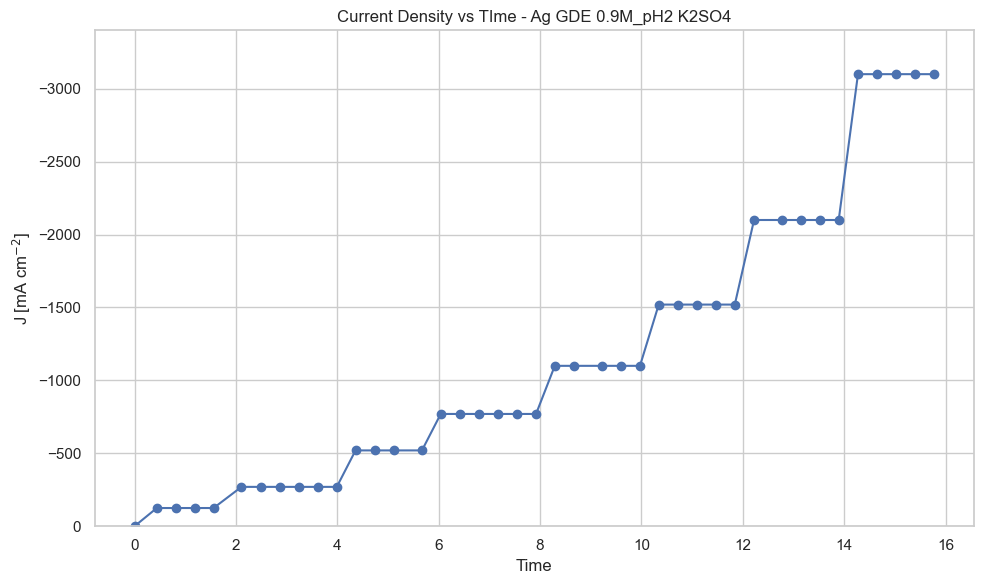

In [64]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.9M_pH2 K2SO4')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

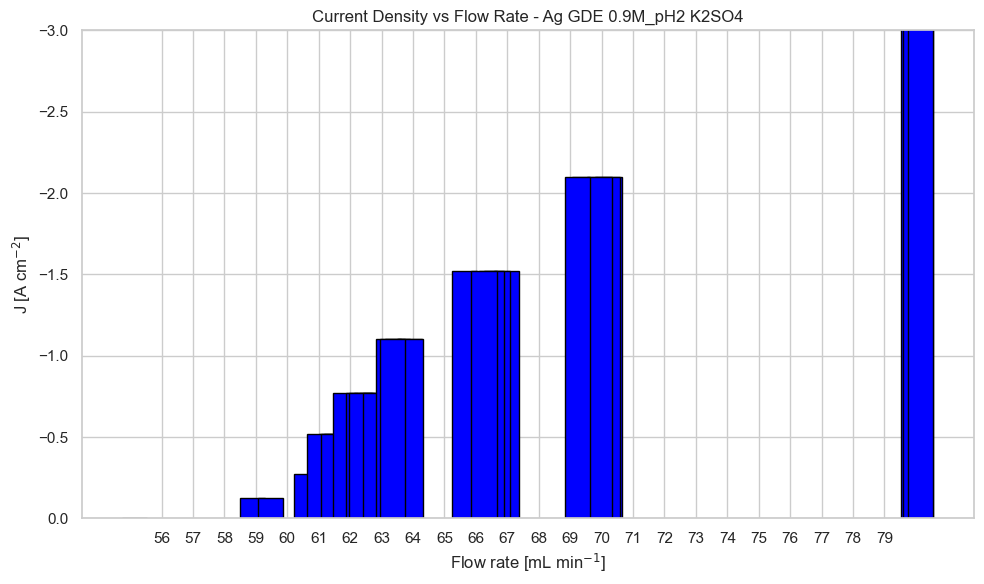

In [65]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.9M_pH2 K2SO4')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


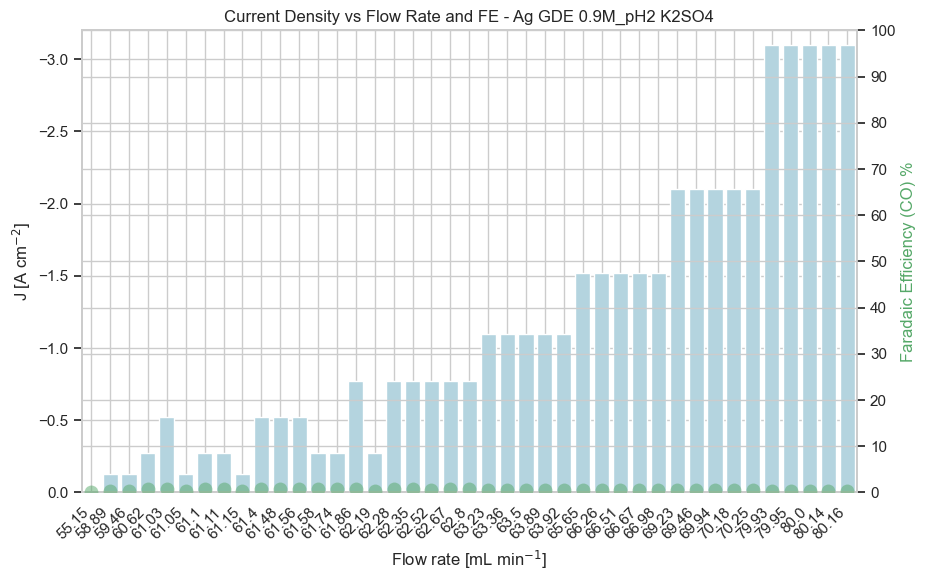

In [66]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.9M_pH2 K2SO4')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240607_Ag_GDE_0_9M_pH2_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [67]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [68]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240607 - Ag60 GDE_0.9 M K2SO4_pH2

11-Aug-26  09:19 AM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  09:14 PM    <DIR>          .ipynb_checkpoints
10-Jun-24  02:41 PM           138,135 0p9M_pH2 K2SO4_20240610_1240_1min - Copy.xlsx
29-Jul-26  06:49 PM            90,150 0p9M_pH2 K2SO4_20240610_1240_1min.xlsx
10-Jun-24  02:41 PM            32,483 0p9M_pH2 K2SO4_20240610_1240_5min.xlsx
10-Jun-24  02:40 PM           942,761 0p9M_pH2 K2SO4_20240610_1240_Line_1.csv
12-May-25  11:31 AM           850,234 20240607 - Ag60 GDE_0.9 M K2SO4_pH2.ipynb
11-Aug-26  09:19 AM           673,034 20240607 - Ag60 GDE_0.9 M K2SO4_pH2-CORRECTED.ipynb
11-Aug-26  09:18 AM               573 20240607_0.9 M K2SO4_pH2_Energy Consumption.csv
04-Aug-26  08:05 PM             5,070 20240607_0.9M K2SO4_pH2.csv
11-Aug-26  09:18 AM             1,405 20

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


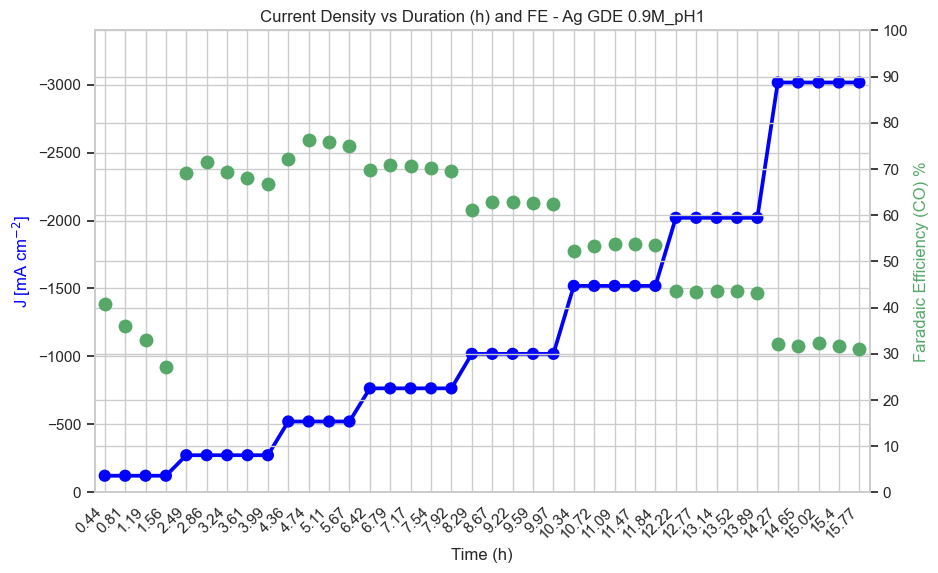

In [71]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.9M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240607_Ag_GDE_0_9M_pH2_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points from initial step in each current

In [70]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.11].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.04].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,58.89,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-07 17:19:44,0.44,0.850289,...,58.89,0.0,-122.0,0.125,0.122,56.946241,53.568617,59.297825,57.19944,89.519543
2,Ag60 GDE in PTFE holder,60,59.46,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-07 17:42:16,0.81,1.006437,...,59.46,0.0,-122.0,0.125,0.122,56.946241,53.568617,59.297825,57.19944,93.862155
3,Ag60 GDE in PTFE holder,60,61.15,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-07 18:04:47,1.19,1.063103,...,61.15,1.0,-122.0,0.125,0.122,56.946241,53.568617,59.297825,57.19944,94.123558
4,Ag60 GDE in PTFE holder,60,61.05,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-07 18:27:17,1.56,1.138060,...,61.05,1.0,-122.0,0.125,0.122,56.946241,53.568617,59.297825,57.19944,92.904407
5,Ag60 GDE in PTFE holder,60,60.62,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 20:52:49,3.99,0.955826,...,60.62,3.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,92.499353
6,Ag60 GDE in PTFE holder,60,61.74,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 20:30:19,3.61,0.907048,...,61.74,3.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,92.493427
7,Ag60 GDE in PTFE holder,60,61.58,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 20:07:48,3.24,0.851302,...,61.58,3.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,92.312765
8,Ag60 GDE in PTFE holder,60,61.10,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 19:22:47,2.49,0.751120,...,61.10,2.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,89.421171
10,Ag60 GDE in PTFE holder,60,61.11,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.273,2024-06-07 19:45:18,2.86,0.791909,...,61.11,2.0,-273.0,0.270,0.273,59.421729,57.547996,60.656304,59.466983,92.786067
11,Ag60 GDE in PTFE holder,60,61.40,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.521,2024-06-07 21:15:20,4.36,0.856986,...,61.40,4.0,-521.0,0.520,0.521,59.880306,58.843983,60.789411,59.878915,84.506760


## Current Density vs FE(CO)_ mean and std

### Stacked bar plot

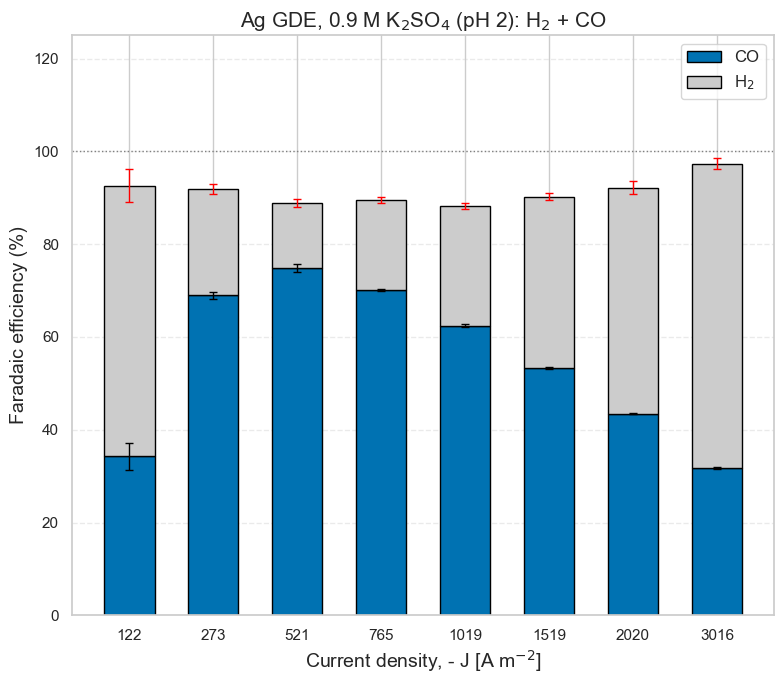

In [72]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M K$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

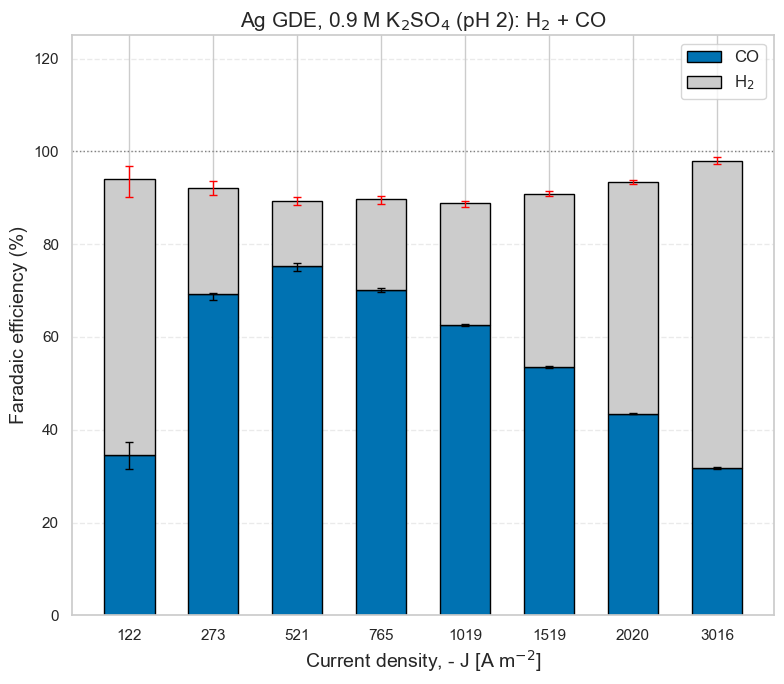

In [75]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M K$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [76]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [77]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,58.360453,34.241963,59.460486,34.532371,3.592759,2.854223,7.185519,5.708447,55.519934,...,0.009602,4,3.940552,2.840519,3.014605,2.724198,1.325090,0.544225,0–2,122
1,250,22.942008,68.960549,22.926038,69.185197,1.000328,0.777503,2.236802,1.738549,21.349672,...,0.007968,5,1.576366,1.521998,1.139807,0.201530,0.180662,0.005926,2–4,273
2,500,14.047013,74.791347,13.894595,75.335123,0.831572,0.898225,1.663144,1.796450,13.032091,...,0.009153,4,0.862504,1.014922,1.123538,0.579762,1.639377,0.554690,4–6,521
3,750,19.416704,70.142998,19.616184,70.091689,0.599041,0.267470,1.339496,0.598080,18.651724,...,0.018782,5,0.964460,0.705651,0.414591,0.552086,0.764131,0.129753,6–8,765
4,1000,25.763111,62.372076,26.203286,62.599727,0.647236,0.323090,1.447265,0.722451,25.486960,...,0.032885,5,0.716326,0.427089,0.218644,0.249550,0.669174,0.177539,8–10,1019
5,1500,36.921244,53.294200,37.269678,53.553817,0.740605,0.297075,1.656042,0.664281,36.837402,...,0.066940,5,0.432276,0.600361,0.180939,0.104224,0.812656,0.505143,10–12,1519
6,2000,48.753090,43.444362,49.868414,43.478149,1.380031,0.069192,3.085843,0.154718,49.393417,...,0.112596,5,0.474998,0.508125,0.026216,0.060932,0.562146,0.447193,12–14,2020
7,3000,65.659368,31.712460,66.281237,31.715654,1.157892,0.233765,2.589124,0.522714,65.626774,...,0.197194,5,0.654463,0.828422,0.139723,0.290024,1.269723,0.073440,14–16,3016


In [80]:
Res_Book
# Res_Book.to_csv('20240607_0.9M K2SO4_pH2.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,58.360453,34.241963,59.460486,34.532371,3.592759,2.854223,7.185519,5.708447,55.519934,...,0.009602,4,3.940552,2.840519,3.014605,2.724198,1.325090,0.544225,0–2,122
1,250,22.942008,68.960549,22.926038,69.185197,1.000328,0.777503,2.236802,1.738549,21.349672,...,0.007968,5,1.576366,1.521998,1.139807,0.201530,0.180662,0.005926,2–4,273
2,500,14.047013,74.791347,13.894595,75.335123,0.831572,0.898225,1.663144,1.796450,13.032091,...,0.009153,4,0.862504,1.014922,1.123538,0.579762,1.639377,0.554690,4–6,521
3,750,19.416704,70.142998,19.616184,70.091689,0.599041,0.267470,1.339496,0.598080,18.651724,...,0.018782,5,0.964460,0.705651,0.414591,0.552086,0.764131,0.129753,6–8,765
4,1000,25.763111,62.372076,26.203286,62.599727,0.647236,0.323090,1.447265,0.722451,25.486960,...,0.032885,5,0.716326,0.427089,0.218644,0.249550,0.669174,0.177539,8–10,1019
5,1500,36.921244,53.294200,37.269678,53.553817,0.740605,0.297075,1.656042,0.664281,36.837402,...,0.066940,5,0.432276,0.600361,0.180939,0.104224,0.812656,0.505143,10–12,1519
6,2000,48.753090,43.444362,49.868414,43.478149,1.380031,0.069192,3.085843,0.154718,49.393417,...,0.112596,5,0.474998,0.508125,0.026216,0.060932,0.562146,0.447193,12–14,2020
7,3000,65.659368,31.712460,66.281237,31.715654,1.157892,0.233765,2.589124,0.522714,65.626774,...,0.197194,5,0.654463,0.828422,0.139723,0.290024,1.269723,0.073440,14–16,3016


## Mean and StD of FE(CO) through time

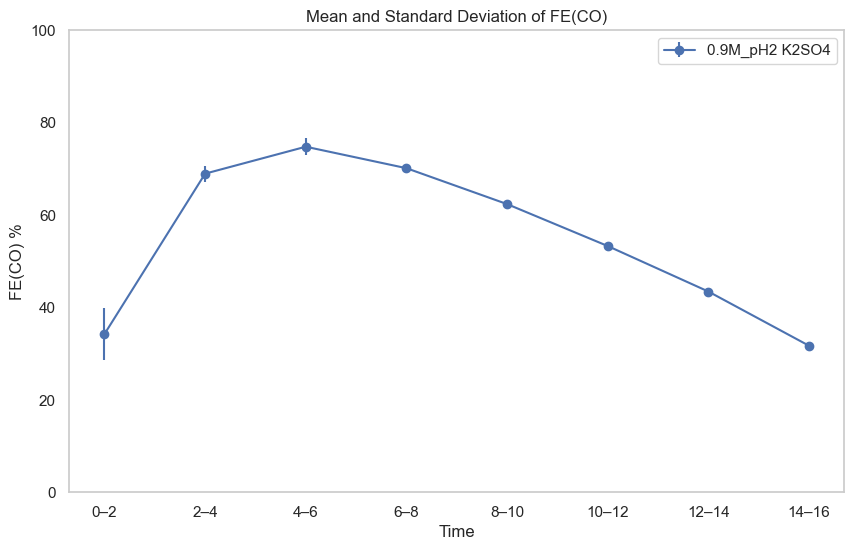

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.9M_pH2 K2SO4')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240607_0.9M_pH2_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

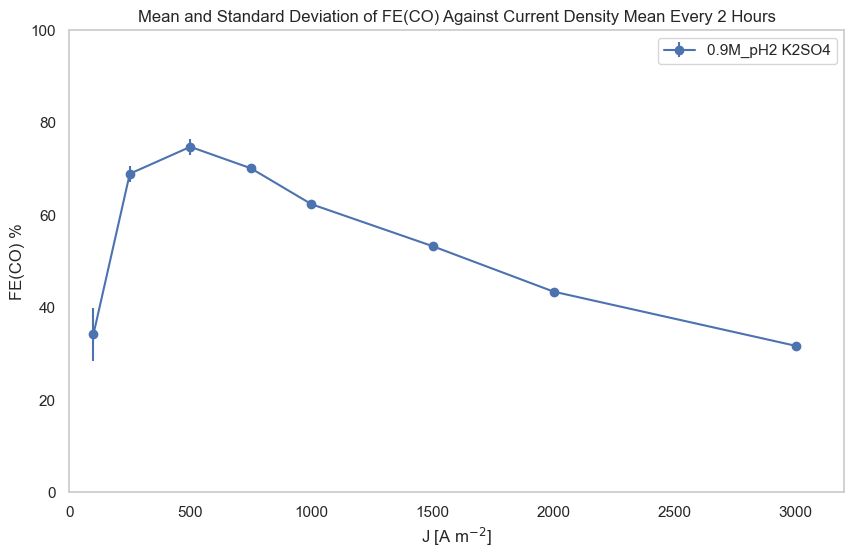

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.9M_pH2 K2SO4')

# Formatting the plot
ax.set_xlabel(r'J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240607_0.9M_pH2_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()